# Notebook to generate Supplementary figure: time in border vs trapezes in Group 2 mice

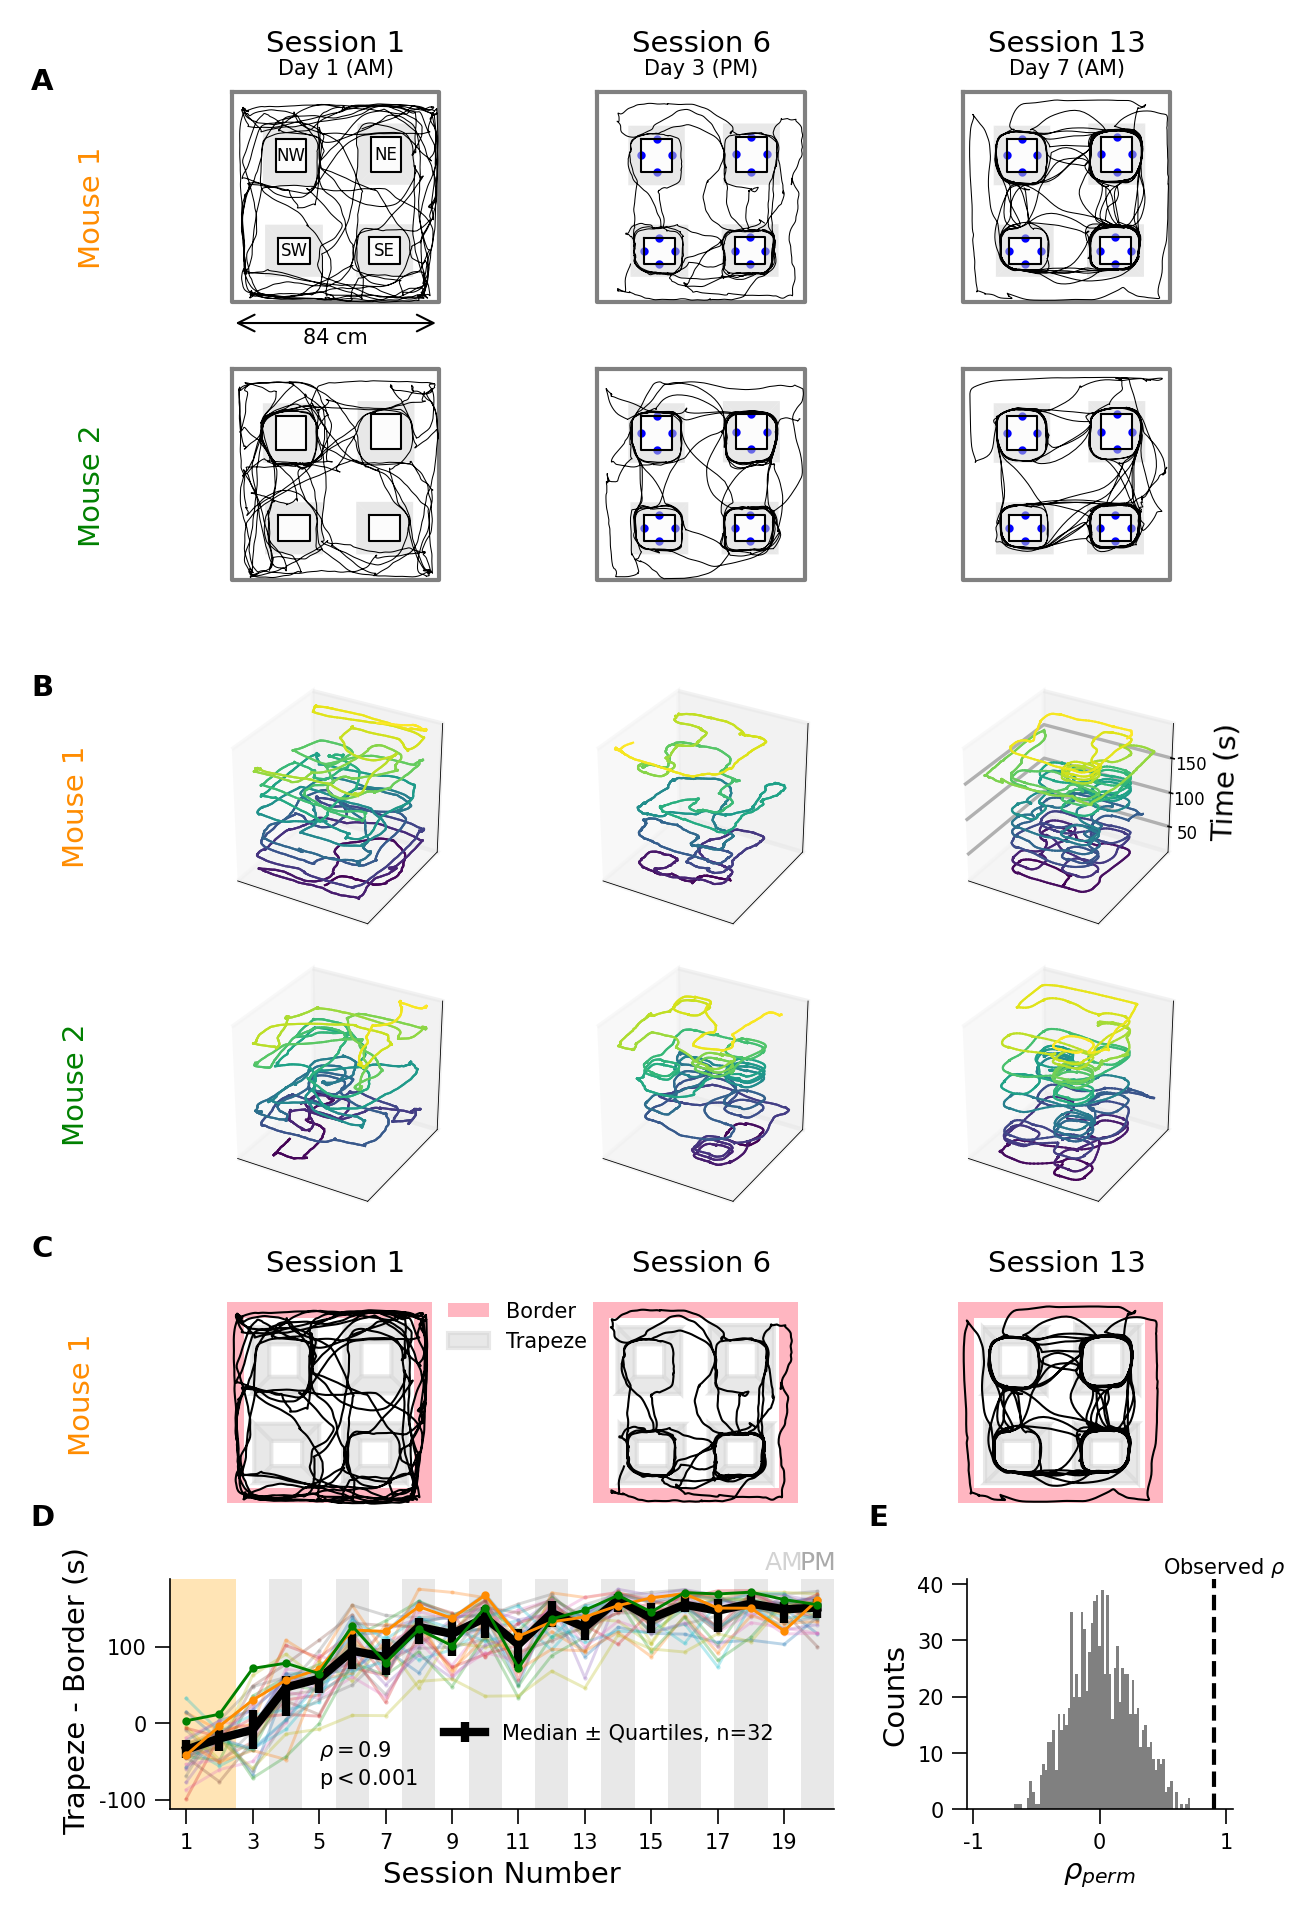

In [21]:
from IPython.display import display
from PIL import Image

# Load and display the image
img = Image.open("FigureS07.png")
display(img)

# 1. Importing necessary libraries and general functions  

In [2]:
from processing_TowerCoordinates import *
from processing_session_trajectory import *
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.path as mpath
import matplotlib.cm as cm
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
import numpy as np
import pickle
import scipy.ndimage as ndimage
from scipy.stats import spearmanr
from bisect import bisect
from datetime import date

plt.style.use('paper.mplstyle')


In [3]:
plotintermediatesteps = False 

# 2. Select mice that will be analysed in the figure
### Define the data_folder where your MOU* folders are, enter the list of mice (MOU* folders), define the sessions indices that will be analyed/plotted 

In [4]:
# defining data folder path and mice list

# path_to_data_folder is the path of the folder where you store the folders of your different mice.

# path_to_data_folder = '/Users/davidrobbe/Documents/Science/Data/ForagingMice/Group2Data/'
path_to_data_folder='/LocalData/ForagingMice/4TowersTaskMethodPaper_Data/Group2Data/'
#path_to_data_folder='/home/david/LocalData/4TowersTask_MethodPaper/Group2Data'
path_to_data_folder = '/home/tom/Code/tower_foraging_park_data/Group2Data'

# Analysing the entire group of mice
mice_to_analyse = ['MOU3974','MOU3975', 'MOU3987', 'MOU3988', 'MOU3991', 'MOU3992', 'MOU4551', 'MOU4552', 'MOU4560', 'MOU4561', 'MOU4562',
                   'MOU4563', 'MOU4623', 'MOU4964', 'MOU4965', 'MOU4986', 'MOU4987', 'MOU4988', 'MOU4993', 'MOU5007', 'MOU5008','MOU5130',
                   'MOU5131', 'MOU5136', 'MOU5140', 'MOU5142', 'MOU5143', 'MOU5144', 'MOU5145', 'MOU5148', 'MOU5149', 'MOU5158']

# Verify that all folders in mice_to_analyse are present in path_to_data_folder
missing_folders = [mouse for mouse in mice_to_analyse if not os.path.isdir(os.path.join(path_to_data_folder, mouse))]

if missing_folders:
    print("Missing mice folders:", missing_folders)
else:
    print("All mice folders are present in data folder.")

# Print the number of mice, the list of mice
print(f' {len(mice_to_analyse)} {"mice" if len(mice_to_analyse) > 1 else "mouse"} will be analysed\n')

# Select the number of sessions that will be analysed for each mice knowing the analysis starts with the first session (familiarisation)
first_and_last_session_indexes = [0,20]
# Select the number of sessions that will be in statistics
first_and_last_session_indexes_stats = [1,20]
# Setting the seed for random processes used in statistics
seed = 27
np.random.seed(seed)

All mice folders are present in data folder.
 32 mice will be analysed



# 3. General functions

In [5]:
def cm2inch(value):

    """
    Converts centimeters to inches for figure size.

    Arguments:
        value (float): value to convert in cm 

    """

    return value/2.54


# 4. Panel A
### Plot some chunk of trajectory for three illustrative sessions of two illustrative mice  

In [6]:
# Chosing mice that will be used as examples
illustration_mice = ['MOU3974', 'MOU3975']

# Chosing index of the sessions to show as examples. They are chosen by their index (session 0 is the first session etc.)
illustration_sessions_indexes = [0, 5, 12]

# Chosing start and end times (s) of chunk of trajectory  to plot 
time_start = 15
time_end = 195

# coordinates in cm of the external walls of the arena [[upperleft x, upperleft y], [upperright x, upperright y], [lowerright x, lowerright y], [lowerleft x, lowerleft y]]
arena_coordinates_cm=[[2.5, 91.7], [90.3, 91.7], [90.3, 2.7], [2.5, 2.7]]

# Set the limits of the x-axis on the statistics plots
xlim_stats = [first_and_last_session_indexes[0]+0.5,first_and_last_session_indexes[1]+0.5]


### Define the functions that: 
#### 1) plot the trajectory (plot_trajectory_and_maze) 
#### 2) loops accross mice and sessions to load the trajectory and plot them (load_and_plot_sessions)

In [7]:
def plot_trajectory_on_maze(arena_coordinates, tower_coordinates, all_trapezes_coordinates, reward_spouts_coordinates,
                            xpositions, ypositions, time_video_frames, chunk_start=None, chunk_end=None,
                            towerscolor=['k', 'k', 'k', 'k'], showtowerID=True, showspoutID=False, showdrops=True, show_arena_size=False, ax=None):
    """
    Plots the trajectory of a mouse on a maze with various elements like towers, reward spouts, and trapezes.

    Arguments:
        arena_coordinates (list): Coordinates defining the perimeter of the arena.
        tower_coordinates (list): Dictionary with tower names as keys and their vertex coordinates as values.
        all_trapezes_coordinates (list): Dictionary with tower names as keys and their associated trapeze coordinates as values.
        reward_spouts_coordinates (list): Dictionary with tower names as keys and their associated reward spout coordinates as values.
        xpositions (list): X-coordinates of the mouse's trajectory.
        ypositions (list): Y-coordinates of the mouse's trajectory.
        time_video_frames (list): Time stamps corresponding to the video frames.
        chunk_start (float, optional): Start time for plotting a chunk of the trajectory.
        chunk_end (float, optional): End time for plotting a chunk of the trajectory.
        towerscolor (list, optional): List of colors for the towers.
        showtowerID (bool, optional): Boolean to show tower IDs.
        showspoutID (bool, optional): Boolean to show reward spout IDs.
        showdrops (bool, optional): Boolean to show reward drops.
        show_arena_size (bool, optional): Boolean to show the arena size indicator.
        ax (matplotlib.axes.Axes, optional): Matplotlib axis object for plotting.
    """
    
    # Create a new figure and axis if no axis is provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    # Draw the arena perimeter
    arena_x, arena_y = zip(*arena_coordinates + [arena_coordinates[0]])
    ax.plot(arena_x, arena_y, 'grey', linewidth=1)

    # Plot each tower
    for i, (tower_name, vertices) in enumerate(tower_coordinates.items()):
        tower_x, tower_y = zip(*vertices + [vertices[0]])
        ax.fill(tower_x, tower_y, towerscolor[i], alpha=0.01)
        ax.plot(tower_x, tower_y, 'k-', linewidth=0.5)
        if showtowerID:
            centroid_x = sum(x for x, y in vertices) / 4
            centroid_y = sum(y for x, y in vertices) / 4
            ax.text(centroid_x, centroid_y, tower_name, color='k', fontsize=4, ha='center', va='center', fontweight='normal')

    # Plot reward spouts as big blue dots with optional wall face ID
    if showdrops:
        for tower, spouts in reward_spouts_coordinates.items():
            for wall, (x, y) in spouts.items():
                ax.scatter(x, y, color='blue', s=1)
                if showspoutID:
                    ax.text(x, y, wall, color='black', fontsize=12, ha='center', va='center', fontweight='bold')

    # Plot each square and trapeze with the same color for each tower
    for i, (tower, trapezes) in enumerate(all_trapezes_coordinates.items()):
        for trapeze, coordinates in trapezes.items():
            coordinates_copy = coordinates + [coordinates[0]]
            x_coords, y_coords = zip(*coordinates_copy)
            ax.fill(x_coords, y_coords, 'lightgray', alpha=0.5)

    # Plot the entire trajectory of the mouse or just a chunk
    if chunk_start is None:
        chunk_start = time_video_frames[0]
    if chunk_end is None:
        chunk_end = time_video_frames[-1]

    start_idx = np.searchsorted(time_video_frames, chunk_start)
    end_idx = np.searchsorted(time_video_frames, chunk_end)

    ax.plot(xpositions[start_idx:end_idx], ypositions[start_idx:end_idx], label='Trajectory', color='k', linewidth=0.25)

    # Draw arena size indicator if enabled
    arena_min_x = min(x for x, y in arena_coordinates)
    arena_max_x = max(x for x, y in arena_coordinates)
    arena_min_y = min(y for x, y in arena_coordinates)
    arena_max_y = max(y for x, y in arena_coordinates)

    arrow_y = arena_min_y - 0.1 * (arena_max_y - arena_min_y)
    if show_arena_size:
        ax.annotate('', xy=(arena_min_x-2, arrow_y), xytext=(arena_max_x+2, arrow_y),
                    arrowprops=dict(arrowstyle='<->', linewidth=0.5))
        ax.text((arena_min_x + arena_max_x) / 2, arrow_y - 2, '84 cm', ha='center', va='top', fontsize=5, fontweight='normal')

    # Set plot limits and remove axes/grid
    ax.set_xlim(arena_min_x-(arena_max_x-arena_min_x)*0.05, arena_max_x+(arena_max_x-arena_min_x)*0.05)
    ax.set_ylim(arrow_y - (arena_max_y-arena_min_y)*0.05, arena_max_y + (arena_max_y-arena_min_y)*0.05)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

def plot_mouse_sessions(illustration_mouse_name, sessions_indexes_to_plot, path_to_data_folder, time_start=None, time_end=None, axs=None,show_arena_size=None,showtowerID=None):
    
    """
    Uses plot_trajectory_with_trapezes to plot the trajectory along with trapezes for all the selected sessions.

    Arguments:
        illustration_mouse_name (strings): Mouse's name
        sessions_indexes_to_plot (int): indexes of session's of which the trajectory will be plotted
        path_to_data_folder (string): path of the folder where you store your the folders of your different mice
        time_start (float, optional): Time of the at which the trajectory will start being displayed
        time_end (float, optional): Time of the at which the trajectory will stop being displayed
        axs (list of matplotlib.axes.Axes, optional): list of ax objects in which to plot the trajectories
        linewidth (float, optional): Thickness of trajectories lines
        showtowerID (bool): If True, shows the IDs of the towers
    """

    # Number of sessions
    num_sessions = len(sessions_indexes_to_plot)
        
    # Ensure axs is 2D array, even if there is only one row or column
    axs = np.array(axs)
    if num_sessions == 1:
        axs = np.expand_dims(axs, axis=1)

    # Iterate through each mouse
    
    folder_path_mouse_to_analyse = os.path.join(path_to_data_folder, illustration_mouse_name)

    # Get the list of sessions for the current mouse
    sessions_to_analyse = sorted([name for name in os.listdir(folder_path_mouse_to_analyse)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
                                  and name.startswith('MOU')])

    # Iterate through each session for the current mouse
    for session_idx, session_to_plot_index in enumerate(sessions_indexes_to_plot):
        session_to_plot = sessions_to_analyse[session_to_plot_index]

        # For the first session, extract trapeze and tower data (you can adjust if needed)
        if session_idx == 0:
            trapeze_width, towers_coordinates = get_trapeze_and_tower_data(folder_path_mouse_to_analyse, session_to_plot)
            all_trapezes_coordinates_cm,towers_coordinates_cm = generate_trapeze_and_tower_coordinates(towers_coordinates, trapeze_width)
            reward_spouts_coordinates_cm = get_reward_spouts(towers_coordinates_cm)
            if show_arena_size is None:
                show_arena_size=True
            if showtowerID is None:
                showtowerID=True
            showdrops=False
                
        else:
            show_arena_size=False
            showtowerID=False
            showdrops=True

        # Define the pickle file path
        output_pickle_filename = f"{session_to_plot}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_plot, output_pickle_filename)
            
        # Check if the pickle file exists
        if not os.path.exists(output_pickle_filepath):
            print(f'Pickle file does not exist for session {session_to_plot}, skipping .....')
            continue
            
        # Load the pickle file
        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)
            
        # Get the positions
        positions = np.array(session_data['positions'])
        times_videoFrames = np.array(session_data['timeofframes'])

        # Plot the trajectory on the respective subplot            

        plot_trajectory_on_maze(arena_coordinates_cm, towers_coordinates_cm, all_trapezes_coordinates_cm, reward_spouts_coordinates_cm, 
                      positions[0, :], positions[1, :], times_videoFrames, chunk_start=time_start,chunk_end=time_end,showdrops=showdrops,show_arena_size=show_arena_size,showtowerID=showtowerID, ax=axs[session_idx])
 

In [8]:
if plotintermediatesteps:
    fig = plt.figure(figsize=(cm2inch(12), cm2inch(9)), dpi=300, constrained_layout=False, facecolor='w')

    gs = fig.add_gridspec(2, 1 , hspace=0.5, height_ratios=[1, 1])

    ### Panel A ###

    row1 = gs[0:2].subgridspec(2, 3, wspace=.3, hspace=.1, width_ratios=[1, 1, 1])
    ax_11 = plt.subplot(row1[0,0], aspect="equal")
    ax_12 = plt.subplot(row1[0,1], aspect="equal")
    ax_13 = plt.subplot(row1[0,2], aspect="equal")


    axs_1top = [ax_11,ax_12,ax_13]
    axs_1top = np.array(axs_1top)

    plot_mouse_sessions(illustration_mice[0], illustration_sessions_indexes, path_to_data_folder, time_start=time_start, time_end=time_end, axs=axs_1top)


    ax_11.text(-0.1, 0.5, 'Mouse 1', color='darkorange',rotation=90, va='center', ha='center', transform=ax_11.transAxes, fontsize=7)
    ax_11.text(0.5, 1.1, f'Session {illustration_sessions_indexes[0]+1}', va='center', ha='center', transform=ax_11.transAxes, fontsize=7)
    ax_12.text(0.5, 1.1, f'Session {illustration_sessions_indexes[1]+1}', va='center', ha='center', transform=ax_12.transAxes, fontsize=7)
    ax_13.text(0.5, 1.1, f'Session {illustration_sessions_indexes[2]+1}', va='center', ha='center', transform=ax_13.transAxes, fontsize=7)

    ax_11.text(-0.2, 1, 'A', weight='bold', va='center', ha='center', transform=ax_11.transAxes, fontsize=7)

    ax_14 = plt.subplot(row1[1,0], aspect="equal")
    ax_15 = plt.subplot(row1[1,1], aspect="equal")
    ax_16 = plt.subplot(row1[1,2], aspect="equal")

    axs_1bot = [ax_14,ax_15,ax_16]
    axs_1bot = np.array(axs_1bot)

    plot_mouse_sessions(illustration_mice[1], illustration_sessions_indexes, path_to_data_folder, time_start=time_start, time_end=time_end, axs=axs_1bot,showtowerID=False,show_arena_size=False)

    ax_14.text(-0.1, 0.5, 'Mouse 2', color='green',rotation=90, va='center', ha='center', transform=ax_14.transAxes, fontsize=7)


# 5. Panel B
### 3D Plot of chunks of trajectory for three illustrative sessions of two illustrative mice 

In [9]:
def plot_3d_trajectory(x_coordinates, y_coordinates, times_videoframes, time_start=None, time_end=None, ax=None, linewidth=1, show_zticks_info=None):
    
    """
    #plot_3d_trajectory(x, y, t, time_start=None, time_end=None, ax=None, linewidth=1):
    Plots a 3D trajectory with (x, y) coordinates and time t as the z-axis.
    The color of the trajectory changes gradually from start to end.

    Arguments:
        x_coordinates (list): Trajectory's x coordinates
        y_coordinates (list): Trajectory's y coordinates
        times_videoframes (list): Trajectory's time
        time_start (float, optional): Time of the at which the trajectory will start being displayed
        time_end (float, optional): Time of the at which the trajectory will stop being displayed
        ax (matplotlib.axes.Axes, optional): 3D subplot axis (from plt.Axes). If None, a new axis will be created.
        linewidth (float, optional): Thickness of trajectories lines.
        show_zticks_info (bool, optional): Show the z-axis ticks if True.
    """
    
    # Create a new figure and axis if no axis is provided
    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')

    # Chosing session's period to analyse
    if time_start is None:
        time_start = times_videoframes[0]
    if time_end is None:
        time_end = times_videoframes[-1]

    start_idx = np.searchsorted(times_videoframes, time_start)
    end_idx = np.searchsorted(times_videoframes, time_end)

    # Extract data from the selected period
    selected_x = x_coordinates[start_idx:end_idx] # x_coordinates coordinates
    selected_y = y_coordinates[start_idx:end_idx] # y coordinates
    selected_t = times_videoframes[start_idx:end_idx] # time of points
    
    # Normalize the time for color mapping
    norm = plt.Normalize(selected_t.min(), selected_t.max())
    colors = cm.viridis(norm(selected_t))

    # Plot 3D line with gradient color
    for i in range(len(selected_x) - 1):
        ax.plot(selected_x[i:i+2], selected_y[i:i+2], selected_t[i:i+2], color=colors[i], linewidth=linewidth)

  

    # Hide z label, ticks, and tick labels for all axes
    ax.set_xticks([])
    ax.set_yticks([])
    if not(show_zticks_info) :
        ax.set_zticks([])
    else:
        ax.tick_params(axis='z', pad=-5,labelsize=4)
        ax.set_zlabel("Time (s)", labelpad=-12, rotation='vertical',fontsize=7)

    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.line.set_linewidth(0.2)
 
def plot_3dtrajectory_mice_sessions(illustration_mouse_name, sessions_indexes_to_plot, path_to_data_folder, time_start=None, time_end=None, axs=None, linewidth=1,show_last_zticks_info=False):
    
    """
    Uses plot_3d_trajectory to plots a 3D trajectory for all the selected sessions.
    The color of the trajectory changes gradually from start to end.

    Arguments:
        illustration_mouse_name (list of strings): list of the mice's name
        sessions_indexes_to_plot (list of int): indexes of session's of which the trajectory will be plotted
        path_to_data_folder (string or path): path of the folder where you store your the folders of your different mice
        time_start (int, optional): Time of the at which the trajectory will start being displayed
        time_end (int, optional): Time of the at which the trajectory will stop being displayed
        axs (list of matplotlib.axes.Axes, optional): list of ax objects in which to plot the trajectories
        linewidth (float, optional): Thickness of trajectories lines
        show_last_zticks_info (bool, optional): If True, shows the z-axis ticks on the last plot
    """

    # Number of session
    num_sessions = len(sessions_indexes_to_plot)
    
    # Ensure axs is 2D array, even if there is only one row or column
    if num_sessions == 1:
        axs = np.expand_dims(axs, axis=1)

    # Iterate through each mouse
    
    folder_path_mouse_to_analyse = os.path.join(path_to_data_folder, illustration_mouse_name)

    # Get the list of sessions for the current mouse
    sessions_to_analyse = sorted([name for name in os.listdir(folder_path_mouse_to_analyse)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
                                  and name.startswith('MOU')])

    # Iterate through each session for the current mouse
    for session_idx, session_to_plot_index in enumerate(sessions_indexes_to_plot):
        session_to_plot = sessions_to_analyse[session_to_plot_index]

        # Define the pickle file path
        output_pickle_filename = f"{session_to_plot}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_plot, output_pickle_filename)
            
        # Check if the pickle file exists
        if not os.path.exists(output_pickle_filepath):
            print(f'Pickle file does not exist for session {session_to_plot}, skipping .....')
            continue
            
        # Load the pickle file
        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)
            
        # Get the positions
        positions = np.array(session_data['positions'])
        timeofframes=session_data['timeofframes']

        # Plot the trajectory on the respective subplot
        if show_last_zticks_info and session_idx == 2:
            plot_3d_trajectory(positions[0, :], positions[1, :], timeofframes, ax=axs[session_idx], time_start=time_start, time_end=time_end, linewidth=linewidth, show_zticks_info=True)
        else:
            plot_3d_trajectory(positions[0, :], positions[1, :], timeofframes, ax=axs[session_idx], time_start=time_start, time_end=time_end, linewidth=linewidth, show_zticks_info=False)


### Plotting 3D trajectories for illustrative chunks. This takes time to run (50 s.)

In [10]:
if plotintermediatesteps:
    fig = plt.figure(figsize=(cm2inch(12), cm2inch(9)), dpi=300, constrained_layout=False, facecolor='w')

    gs = fig.add_gridspec(2, 1 , hspace=0.5, height_ratios=[1, 1])

    ### Panel B ###

    row2 = gs[0:2].subgridspec(2, 3, wspace=.1, hspace=.1, width_ratios=[1, 1, 1])
    ax_21 = plt.subplot(row2[0,0], projection="3d", aspect="equal")
    ax_22 = plt.subplot(row2[0,1], projection="3d", aspect="equal")
    ax_23 = plt.subplot(row2[0,2], projection="3d", aspect="equal")

    axs_2top = [ax_21,ax_22,ax_23]
    axs_2top = np.array(axs_2top)

    plot_3dtrajectory_mice_sessions(illustration_mice[0], illustration_sessions_indexes, path_to_data_folder, time_start=time_start, time_end=time_end, axs=axs_2top, linewidth=0.5,show_last_zticks_info=True)

    ax_21.text2D(-0.1, 0.5, 'Mouse 1', color='darkorange',rotation=90, va='center', ha='center', transform=ax_21.transAxes, fontsize=7)
    ax_21.text2D(-0.2, 1, 'B', weight='bold', va='center', ha='center', transform=ax_21.transAxes, fontsize=7)


    ax_24 = plt.subplot(row2[1,0], projection="3d", aspect="equal")
    ax_25 = plt.subplot(row2[1,1], projection="3d", aspect="equal")
    ax_26 = plt.subplot(row2[1,2], projection="3d", aspect="equal")


    axs_2bot = [ax_24,ax_25,ax_26]
    axs_2bot = np.array(axs_2bot)

    plot_3dtrajectory_mice_sessions(illustration_mice[1], illustration_sessions_indexes, path_to_data_folder, time_start=time_start, time_end=time_end, axs=axs_2bot, linewidth=0.5,show_last_zticks_info=False)

    ax_24.text2D(-0.1, 0.5, 'Mouse 2', color='green', rotation=90, va='center', ha='center', transform=ax_24.transAxes, fontsize=7)


# 6. Panels C, D, E
### Here we compute during the first 3 threee minutes of each session the difference between the time spend in the trapezes and the time spend in the border of the maze  

### Setting dimensions of the arena border and the trapze width around the towers

In [11]:
# Coordinates of the rectangles (in centimeters) representing the edges of the setup
border_zone = [
    [(3, 3), (10, 3), (10, 90), (3, 90)],  # left
    [(3, 3), (3, 9.5), (92, 9.5), (92, 3)],  # down
    [(84, 3), (92, 3), (92, 90), (84, 90)],  # right
    [(3, 83), (3, 90), (92, 90), (92, 83)]   # up
]

# With of the trapezes in pixels
trapeze_width = 40

## Panel C

In [12]:
def plot_trajectory_with_trapezes_border(folder_path_mouse_to_analyse, session_idx_to_analyse, border_zone, trapeze_width, ax, time_start=None, time_end=None, linewidth=1, show_legend=True):
    
    """
    This function is used to plot the trajectory of a mouse in a given session with the trapezes and border zones
    Arguments:
        folder_path_mouse_to_analyse (string): path to the folder containing mouse's sessions folders
        session_idx_to_analyse (int): index of the session from which to plot the trajectory
        border_zone (list) : coordinates of the the rectangles defining the border zone
        trapeze_width (float): value in pixel to set up the size of the trapezes
        ax (matplotlib.axes.Axes): ax object in which to plot
        time_start (float, optional): Time of the at which the trajectory will start being displayed
        time_end (float, optional): Time of the at which the trajectory will stop being displayed
        linewidth (float, optional): Thickness of trajectory line
        show_legend (bool, optional): Shows the legend if true

    """
    
    # Get the list of sessions for the current mouse
    sessions_to_analyse = sorted([name for name in os.listdir(folder_path_mouse_to_analyse)
                                if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
                                and name.startswith('MOU')])

    # Store the name of the session to analyse
    session_to_analyse = sessions_to_analyse[session_idx_to_analyse]

    # Define the path to pickle data file of the session
    pickle_file = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, session_to_analyse + '_basic_processing_output.pickle')

    # extract trapeze and tower data
    towers_coordinates=get_trapeze_and_tower_data(folder_path_mouse_to_analyse, session_to_analyse)[1]

   # Load data from pickle file
    with open(pickle_file, 'rb') as f:
        session_data = pickle.load(f)
    
    # Extract the necessary data from the pickle in the selected period
    times_videoFrames = session_data['timeofframes']
    smoothed_xpositions_cm = session_data['positions'][0]
    smoothed_ypositions_cm = session_data['positions'][1]
    all_trapezes_coordinates_cm = generate_trapeze_and_tower_coordinates(towers_coordinates, trapeze_width)[0]

    # Analyze entire session or not
    if time_start is None:
        time_start = times_videoFrames[0]
    if time_end is None:
        time_end = times_videoFrames[-1]

    # Find the indices corresponding to the specified time interval
    start_idx = np.searchsorted(times_videoFrames, time_start)
    end_idx = np.searchsorted(times_videoFrames, time_end)

    # Extract the necessary data from the pickle
    times_videoFrames = session_data['timeofframes']
    smoothed_xpositions_cm = session_data['positions'][0]
    smoothed_ypositions_cm = session_data['positions'][1]
    # Generate trapeze and tower coordinates
    all_trapezes_coordinates_cm, towers_coordinates_cm = generate_trapeze_and_tower_coordinates(towers_coordinates, trapeze_width=40)

    # Extract data from the selected period
    selected_xpositions = smoothed_xpositions_cm[start_idx:end_idx]
    selected_ypositions = smoothed_ypositions_cm[start_idx:end_idx]
    selected_time = times_videoFrames[start_idx:end_idx]

    # Create the polygons for the border area
    border_polygons = [mpath.Path(zone) for zone in border_zone]

    # Create a polygone for the trapezes zones (white)
    trapeze_polygons = []
    for tower, trapezes in all_trapezes_coordinates_cm.items():
        for trapeze, coords in trapezes.items():
            trapeze_polygons.append(mpath.Path(coords))

    # Add the polygons for the border (red)
    for polygon in border_polygons:
        patch = patches.PathPatch(polygon, facecolor='lightpink', alpha=1,linewidth=0, label="Border" if polygon == border_polygons[0] else "")
        ax.add_patch(patch)

    # Add the polygons for the trapezoids (white)
    for polygon in trapeze_polygons:
        patch = patches.PathPatch(polygon, facecolor='lightgray', alpha=0.5, edgecolor='lightgray', label="Trapeze" if polygon == trapeze_polygons[0] else "")
        ax.add_patch(patch)

    # Plot the trajectory
    ax.plot(selected_xpositions, selected_ypositions, color='black', linewidth=linewidth )

    # Hide all spines (removes the box around the plot)
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Remove x and y axis labels and ticks
    ax.set_xticks([])
    ax.set_yticks([])

    # Set x and y axis limits
    ax.set_xlim([0, 100])
    ax.set_ylim([0, 100])

    # Display legend if show_legend is true
    if show_legend:

        ax.legend(frameon=False, loc=(0.95,0.65), ncols=1)


## Panel D

In [13]:
def calculate_time_in_zones(folder_path_mouse_to_analyse, session_to_analyse, border_zone, trapeze_width, time_start=None, time_end=None):
    
    """This function is used to calculate the total time spent in border, inner and trapezes areas during session. 
    Arguments:
        folder_path_mouse_to_analyse (string): path to the folder containing mouse's sessions folders
        session_to_analyse (string): session from which to compute the time and distance difference
        border_zone (dict): dictionnary of coordinates that define the border zone
        trapeze_width (float): value in pixel to set up the size of the trapezes
        time_start (float, optional): Time of the at which the trajectory will start being displayed
        time_end (float, optional): Time of the at which the trajectory will stop being displayed
                
    Outputs: 
        time_spent_in_zones (dict): dictionnary with area as key and time spent inside as value
    """

    # Build the path to the session pickle file
    pickle_file_path = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, session_to_analyse + '_basic_processing_output.pickle')
    
    # Extract trapeze and tower data
    towers_coordinates = get_trapeze_and_tower_data(folder_path_mouse_to_analyse, session_to_analyse)[1]
    
    # Load data from pickle file
    with open(pickle_file_path, 'rb') as f:
        session_data = pickle.load(f)
    
    # Extract the necessary data from the pickle in the selected period
    smoothed_xpositions_cm = session_data['positions'][0] # x coordinates in cm
    smoothed_ypositions_cm = session_data['positions'][1] # y coordinates in cm
    times_videoFrames = session_data['timeofframes'] # Time of points in cm


    all_trapezes_coordinates_cm = generate_trapeze_and_tower_coordinates(towers_coordinates, trapeze_width)[0]

    # Chosing session's period to analyse
    if time_start is None:
        time_start = times_videoFrames[0]
    if time_end is None:
        time_end = times_videoFrames[-1]

    # Find the indices corresponding to the specified time interval
    start_idx = np.searchsorted(times_videoFrames, time_start)
    end_idx = np.searchsorted(times_videoFrames, time_end)

    # Extract data from the selected period
    selected_xpositions = smoothed_xpositions_cm[start_idx:end_idx]
    selected_ypositions = smoothed_ypositions_cm[start_idx:end_idx]
    selected_time = times_videoFrames[start_idx:end_idx]

    # Border zones (red)
    border_polygons = [
        mpath.Path(border_zone[0]),  # Left
        mpath.Path(border_zone[1]),  # Down
        mpath.Path(border_zone[2]),  # Right
        mpath.Path(border_zone[3])   # Up
    ]
    
    # Trapezes zones (white)
    trapeze_polygons = []
    for tower, trapezes in all_trapezes_coordinates_cm.items():
        for trapeze, coords in trapezes.items():
            trapeze_polygons.append(mpath.Path(coords))
    
    # Interior zone (green)
    inner_setup_size = (10, 9.5, 84, 83)
    interior_polygon = mpath.Path([
        (inner_setup_size[0], inner_setup_size[1]),
        (inner_setup_size[0], inner_setup_size[3]),
        (inner_setup_size[2], inner_setup_size[3]),
        (inner_setup_size[2], inner_setup_size[1])
    ])
    
    # Variables to store time and distance spent in each zone
    time_in_border = 0
    time_in_trapeze = 0
    time_in_interior = 0
  
    
    # Iterate on the trajectory positions and calculate the time and distance in each area
    for i in range(len(selected_xpositions) - 1):
        point_start = np.array([selected_xpositions[i], selected_ypositions[i]])

        # Calculate the time interval between each point
        dt = selected_time[i+1] - selected_time[i]

        # Test if the initial point is in the 'border' zone (red)
        if any(polygon.contains_point(point_start) for polygon in border_polygons):
            time_in_border += dt

        # Test if the initial point is in the 'trapeze' (white) area
        elif any(polygon.contains_point(point_start) for polygon in trapeze_polygons):
            time_in_trapeze += dt

        # Test if the initial point is in the inner (green) zone
        elif interior_polygon.contains_point(point_start):
            time_in_interior += dt

    # Return results in a dictionary, rounded to 2 decimal
    time_spent_in_zones = {
        'border': round(time_in_border, 2),
        'trapeze': round(time_in_trapeze, 2),
        'interior': round(time_in_interior, 2)
    }

    
    return time_spent_in_zones


# Computing the time and distance spent in different zones (trapeze vs. border) across mice and sessions
### This takes > 1 min to run. 

In [14]:
# Initialize dictionaries to store time and distance differences for each mouse across sessions
mouse_timediff_trapezevsborder_persession = {mouse: [] for mouse in mice_to_analyse}
mouse_distancediff_trapezevsborder_persession = {mouse: [] for mouse in mice_to_analyse}

# Iterate over each mouse in the analysis list
for mouse in mice_to_analyse:

    folder_path_mouse_to_analyse = os.path.join(path_to_data_folder, mouse)  # Define the mouse's data folder path
    
    # Retrieve and sort session directories for the current mouse
    sessions_to_analyse = sorted([name for name in os.listdir(folder_path_mouse_to_analyse)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
                                  and name.startswith('MOU')])
    
    sessions_to_analyse = sessions_to_analyse[first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

    nb_sessions = len(sessions_to_analyse)  # Count the number of sessions
    print(f'Mouse {mouse}. There is/are {nb_sessions} sessions:')
    
    # Process each session for the current mouse
    for sessionindex, session_to_analyse in enumerate(sessions_to_analyse):
        print(f'Getting the pickle file of session {session_to_analyse}')
        
        # Define the expected output pickle file path
        output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, output_pickle_filename)
        
        # Check if the pickle file exists; if not, skip this session but add a Nan
        if not os.path.exists(output_pickle_filepath):
            print(f'Pickle file does not exist for session {session_to_analyse}, add a Nan and skipping .....')
            # Store the difference between time spent in trapeze and border zones
            mouse_timediff_trapezevsborder_persession[mouse].append([
                sessionindex + 1,  # Session index (1-based)
                np.nan  # Time difference
            ])
            continue  # Skip processing this session
        
        # Calculate time and distance spent in zones (trapeze vs. border)
        time_spentinzones = calculate_time_in_zones(
            folder_path_mouse_to_analyse, session_to_analyse, border_zone, 
            trapeze_width=trapeze_width, time_start=time_start, time_end=time_end
        )
        
        # Store the difference between time spent in trapeze and border zones
        mouse_timediff_trapezevsborder_persession[mouse].append([
            sessionindex + 1,  # Session index (1-based)
            time_spentinzones['trapeze'] - time_spentinzones['border']  # Time difference
        ])


Mouse MOU3974. There is/are 20 sessions:
Getting the pickle file of session MOU3974_20230304-1314
Getting the pickle file of session MOU3974_20230305-1535
Getting the pickle file of session MOU3974_20230306-1211
Getting the pickle file of session MOU3974_20230306-1752
Getting the pickle file of session MOU3974_20230307-1231
Getting the pickle file of session MOU3974_20230307-1742
Getting the pickle file of session MOU3974_20230308-1150
Getting the pickle file of session MOU3974_20230308-1714
Getting the pickle file of session MOU3974_20230309-1155
Getting the pickle file of session MOU3974_20230309-1705
Getting the pickle file of session MOU3974_20230310-1220
Getting the pickle file of session MOU3974_20230310-1702
Getting the pickle file of session MOU3974_20230311-1258
Getting the pickle file of session MOU3974_20230311-1801
Getting the pickle file of session MOU3974_20230312-1145
Getting the pickle file of session MOU3974_20230312-1648
Getting the pickle file of session MOU3974_2023

In [15]:
def plot_learning_curves_alt_background(mouse_metric_persession, ax, mice_list=None, mice_to_highlight=[], mice_to_highlight_labels=[None,None], highlight_colors = ["darkorange", "green"], show_individual_mice=True,
                         median_color='black', show_xlabel=True, ylabel='', main_line_label=None, show_fam=False, 
                         tick_interval=1, index_offset=0, xlim=[None,None], ylim=None, show_legend=True, legend_loc=(0.05, 0.9)):
    """
    Plots a given metric across sessions for multiple mice (also called a learning curves).

    Arguments:
        mouse_metric_persession (dict): Dictionary where keys are mouse IDs and values are lists of (session_index, value) lists.
        mice_list (list, optional): List of mice to include in the plot. Defaults to all mice in the mouse_metric_persession.
        mice_to_highlight (list, optional): List of up to two mice IDs to highlight with distinct colors.
        mice_to_highlight_labels (list, optional): List of the label of the mice to highlight.
        show_individual_mice (bool): If true, plot a line for each individual mouse.
        ax (matplotlib.axes.Axes): Axes object for plotting.
        show_xlabel (bool, optional): Whether to display the x-axis label. Defaults to True.
        ylabel (str, optional): Label for the y-axis.
        main_line_label (str, optional): Label of the median and quartiles range.
        show_fam (bool): Toggle the display of familiarization sessions label
        tick_interval (int, optional): Interval for x-axis tick marks. Defaults to 1.
        index_offset (int, optional): Offset to apply to the numbers in the x axis. Use it if you want to the first sessions to be named '1'.
        xlim (tuple, optional): Tuple specifying x-axis limits. Defaults to None.
        ylim (tuple, optional): Tuple specifying y-axis limits. Defaults to None.
        show_legend (bool, optional): Whether to show the legend. Defaults to True.
        legend_loc (tupple, optional): Location of the legend.
    """

    # If no mice are specified, use all available mice
    if mice_list is None:
        mice_list = list(mouse_metric_persession.keys())

    all_session_indices = set()  # Track all session indices across selected mice
    values_per_session = {}  # Store values for each session across mice

    mice_to_plot = copy.deepcopy(mice_list)

    # Ensure that the mice to hihlight will be plotted and displayed on the legend in order
    if len(mice_to_highlight)>0:

        mice_to_plot.remove(mice_to_highlight[0])
        mice_to_plot.remove(mice_to_highlight[1])

        mice_to_plot = mice_to_highlight + mice_to_plot
    
    # Loop through each mouse and gather session data

    for mouse in mice_to_plot:

        if mouse not in mouse_metric_persession:
            print(f"Mouse {mouse} not found in data. Skipping.")
            continue    

        # Selecting the sub-list of sessions to analyse
        sessions = mouse_metric_persession[mouse]

        # Extract session indices and corresponding values
        session_indices = [session[0] for session in sessions]
        values = [session[1] for session in sessions]

        # Check if there is a nan value in the values list and remove it to allow plotting of lines between points with values
        if sum(np.isnan(x) for x in values)>0:

            session_indices_array=np.array(session_indices)
            values_array=np.array(values)
            mask = ~np.isnan(values_array)
            session_indices=session_indices_array[mask]
            values=values_array[mask]

        # Plot learning curves for each mouse if show_individual_mice is True
        if show_individual_mice:

            if mouse == mice_to_highlight[0]:
                color = highlight_colors[0]
                ax.plot(np.array(session_indices)+index_offset, values, color=color, marker='o', linewidth=0.7, 
                        markersize=1, label= mice_to_highlight_labels[0], zorder=100*len(median_color))

            elif mouse == mice_to_highlight[1]: 
                color = highlight_colors[1]
                ax.plot(np.array(session_indices)+index_offset, values, color=color, marker='o', linewidth=0.7, 
                        markersize=1, label= mice_to_highlight_labels[1], zorder=100*len(median_color))
            
            else:
                ax.plot(np.array(session_indices)+index_offset, values, marker='o', linewidth=0.7, markersize=1, alpha=0.3, markeredgewidth=0.0)

        # Update session index tracking
        all_session_indices.update(session_indices)
        for session, value in sessions:
            if session not in values_per_session:
                values_per_session[session] = []
            values_per_session[session].append(value)

    # Convert session indices to a sorted list
    sorted_sessions = sorted(all_session_indices)

    # Add alternating background color for morning (odd) and afternoon (even) sessions
    for session in sorted_sessions:
        color = 'white' if session % 2 == 1 else 'lightgrey'
        ax.axvspan(session-0.5, session + 0.5, color=color, alpha=0.5, zorder=0, lw=0)

    # Add a single label for 'Matin' and 'Aprem.' above representative sessions
    # We'll pick the first available odd (matin) and even (aprem) sessions
    morning_session = next((s for s in reversed(sorted_sessions) if s % 2 == 1), None)
    afternoon_session = next((s for s in reversed(sorted_sessions) if s % 2 == 0), None)

    ylimits = ax.get_ylim()
    y_text = ylimits[1] + 0.02 * (ylimits[1] - ylimits[0])

    if morning_session is not None:
        ax.text(morning_session, y_text, "AM", fontsize=6, ha='center', va='bottom', fontweight='normal', color='lightgrey')

    if afternoon_session is not None:
        ax.text(afternoon_session, y_text, "PM", fontsize=6, ha='center', va='bottom', fontweight='normal', color='darkgrey')

    # Compute median and 25th-75th percentile range for each session
    median_values = []
    lower_quartile = []
    upper_quartile = []

    for session in sorted_sessions:
        session_values = values_per_session[session]
        median_values.append(np.nanmedian(session_values))
        lower_quartile.append(np.nanpercentile(session_values, 25))
        upper_quartile.append(np.nanpercentile(session_values, 75))

    median_values = np.array(median_values)
    lower_quartile = np.array(lower_quartile)
    upper_quartile = np.array(upper_quartile)

    # If the median and quartiles range don't have a label, give them a default label.
    if not main_line_label:

        main_line_label = f'Median \u00B1 Quartiles, n={len(mice_list)}'

    # Plot median learning curve with shaded 25th-75th percentile range
    ax.errorbar(np.array(sorted_sessions)+index_offset, median_values, yerr=[median_values-lower_quartile, upper_quartile-median_values], alpha=1, color=median_color, linewidth = 2, label=main_line_label, zorder=50*len(median_color))

    # Set axis labels and formatting
    if show_xlabel:
        ax.set_xlabel('Session Number', fontsize=7)
    
    ax.set_ylabel(ylabel, fontsize=7)

    # Ensure x-axis labels are integers
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    # Set x-ticks at specified intervals
    if all_session_indices:
        max_index = max(all_session_indices)
        ax.set_xticks(range(1+index_offset, max_index + 1+index_offset, tick_interval))

    # Apply x and y axis limits if provided
    if xlim is not None:
        ax.set_xlim(xlim)
    
    if ylim is not None:
        ax.set_ylim(ylim)

    ylimits = ax.get_ylim()  # Get the current y-limits
    rectangle_height = abs(ylimits[1]-ylimits[0])  # Calculate the height of the rectangle


    # Define the rectangle position and size
    rect = patches.Rectangle((0.5, ylimits[0]), 2, rectangle_height, color='moccasin', alpha=1, lw=0)  # (x_start, y_start), width, height

    # Add rectangle to the plot
    ax.add_patch(rect)

    if show_fam:
        # Add text label on top of the rectangle
        ax.text(1.5, ylimits[1], "Fam.", fontsize=6, ha='center', va='bottom', fontweight='normal', color='orange', alpha=0.6)

    # Show legend if required
    if show_legend:

        ax.legend(frameon=False, loc=legend_loc, )




# Panel E

In [16]:
def plot_shuffled_spearman_test(mouse_values_persession, ax, shuffle_number, illustration_mouse_name = None, first_and_last_session_indexes=[None,None]):
    
    """
    Plots the value associated with each session for every mice. Plots the median and the quartiles of all mice as well.

    Arguments:
        mouse_value_persession (dict): Dictionary with session numbers as keys and the corresponding values as entries
        ax (matplotlib.axes.Axes): ax object in which to plot
        illustration_mouse_name (list, optional): List of mice from mouse_values_persession to use
        mice_to_highlight (list, optional): List of mice's name whose corresponding line will be highlighted on the plot
        first_and_last_session_indexes (list, optional): List containing indexes of first and last session to plot
        ylabel (string, optional): Name of y label
        tick_interval (int, optional): interval between each tick displayed on the x axis
        xlim (string, optional): display limit on x axis
        ylim (string, optional): display limit on y axis
    """

    if illustration_mouse_name is None:
        illustration_mouse_name = list(mouse_values_persession.keys())

    spearman_rho_list = []
    
    for _ in range(shuffle_number):

        shuffled_values_list = []
        
        for mouse in illustration_mouse_name:

            # Checking if the current mouse has no value to plot
            if mouse not in mouse_values_persession:
                print(f"Mouse {mouse} not found in data. Skipping.")
                continue    

            # Selecting sessions under the limit
            sessions = mouse_values_persession[mouse][first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

            session_indices = [session[0] for session in sessions]
            shuffled_values = np.random.choice([session[1] for session in sessions], size=len(sessions), replace=False)
            
            # np.random.shuffle(shuffled_values)

            shuffled_values_list.append(shuffled_values)

        median_values = np.nanmedian(shuffled_values_list,axis=0)
        spearman_result = spearmanr(session_indices, median_values)
        
        spearman_rho_list.append(spearman_result[0])
    
    values_list = []

    for mouse in illustration_mouse_name:

        # Checking if the current mouse has no value to plot
        if mouse not in mouse_values_persession:
            print(f"Mouse {mouse} not found in data. Skipping.")
            continue    

        # Selecting sessions under the limit
        sessions = mouse_values_persession[mouse][first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

        session_indices = [session[0] for session in sessions]
        values = [session[1] for session in sessions]

        values_list.append(values)

    observed_median_values = np.nanmedian(values_list,axis=0)


    observed_spearman_result = spearmanr(session_indices,observed_median_values)
    observed_rho = observed_spearman_result[0]
    p_value = len(spearman_rho_list[bisect(np.sort(spearman_rho_list), observed_rho):])/len(spearman_rho_list)
    
    print('observed rho : ', observed_rho, 'P value : ', p_value)

    ax.hist(spearman_rho_list, bins=np.linspace(-1,1,100), color='grey')
    ax.axvline(observed_rho, ymax=30, color='black', linestyle='--')
    ax.set_xlabel(r'$\rho_{perm}$')
    ax.set_ylabel('Counts')
    ax.set_xlim([-1.05,1.05])

    return observed_spearman_result

## Generate panel C, D, E

In [17]:
if plotintermediatesteps:
    fig = plt.figure(figsize=(cm2inch(18), cm2inch(9)), dpi=300, constrained_layout=False, facecolor='w')

    gs = fig.add_gridspec(2, 1 , hspace=0.5, height_ratios=[1, 1])

    ### Panel C, D, E ###


    row3 = gs[:2].subgridspec(2, 3, wspace=.3, hspace=.1, width_ratios=[1, 1, 1])
    ax_31 = plt.subplot(row3[0,0], aspect="equal")
    ax_32 = plt.subplot(row3[0,1], aspect="equal")
    ax_33 = plt.subplot(row3[1,:2])
    ax_34 = plt.subplot(row3[0:,2])

    plot_trajectory_with_trapezes_border(os.path.join(path_to_data_folder, illustration_mice[0]), illustration_sessions_indexes[0], border_zone, trapeze_width, ax_31, time_start=time_start, time_end=time_end, linewidth=0.5)
    plot_trajectory_with_trapezes_border(os.path.join(path_to_data_folder, illustration_mice[0]), illustration_sessions_indexes[-1], border_zone, trapeze_width, ax_32, time_start=time_start, time_end=time_end, linewidth=0.5, show_legend=False)

    ax_31.set_xlabel(f'Session {illustration_sessions_indexes[0]+1}')
    ax_31.xaxis.set_label_position('top') 
    ax_31.set_ylabel('Mouse 1', color='darkorange')
    ax_32.set_xlabel(f'Session {illustration_sessions_indexes[-1]+1}')
    ax_32.xaxis.set_label_position('top') 

    plot_learning_curves_alt_background(mouse_timediff_trapezevsborder_persession, ax_33, mice_to_highlight=illustration_mice, first_and_last_session_indexes=first_and_last_session_indexes, ylabel=' Trapeze - Border (s)', tick_interval=2)

    plot_shuffled_spearman_test(mouse_timediff_trapezevsborder_persession, ax_34, shuffle_number=1000, first_and_last_session_indexes=[1,None], text_loc=(0.7,40), legend_loc=(0.05,1))    

    ax_31.text(-0.2, 1.05, 'C', weight='bold', va='center', ha='center', transform=ax_31.transAxes, fontsize=7)
    ax_31.text(-0.2, -0.1, 'D', weight='bold', va='center', ha='center', transform=ax_31.transAxes, fontsize=7)
    ax_31.text(2.3, 1.05, 'E', weight='bold', va='center', ha='center', transform=ax_31.transAxes, fontsize=7)
    

# 7. Whole figure

In [18]:
def get_day_and_period(session_idx):

    """
    Output the day and period of the input session.

    Argument:
        session_idx (int): index of the session to analyse

    Output:
        day (int): Number of the day
        period (str): Label of the day period (AM or PM)
    """

    day = session_idx // 2 + 1
    period = 'AM' if session_idx % 2 == 0 else 'PM'
    
    return day, period


## Generate full figure

observed rho :  0.9 P value :  0.0


/tmp/ipykernel_34826/553271912.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


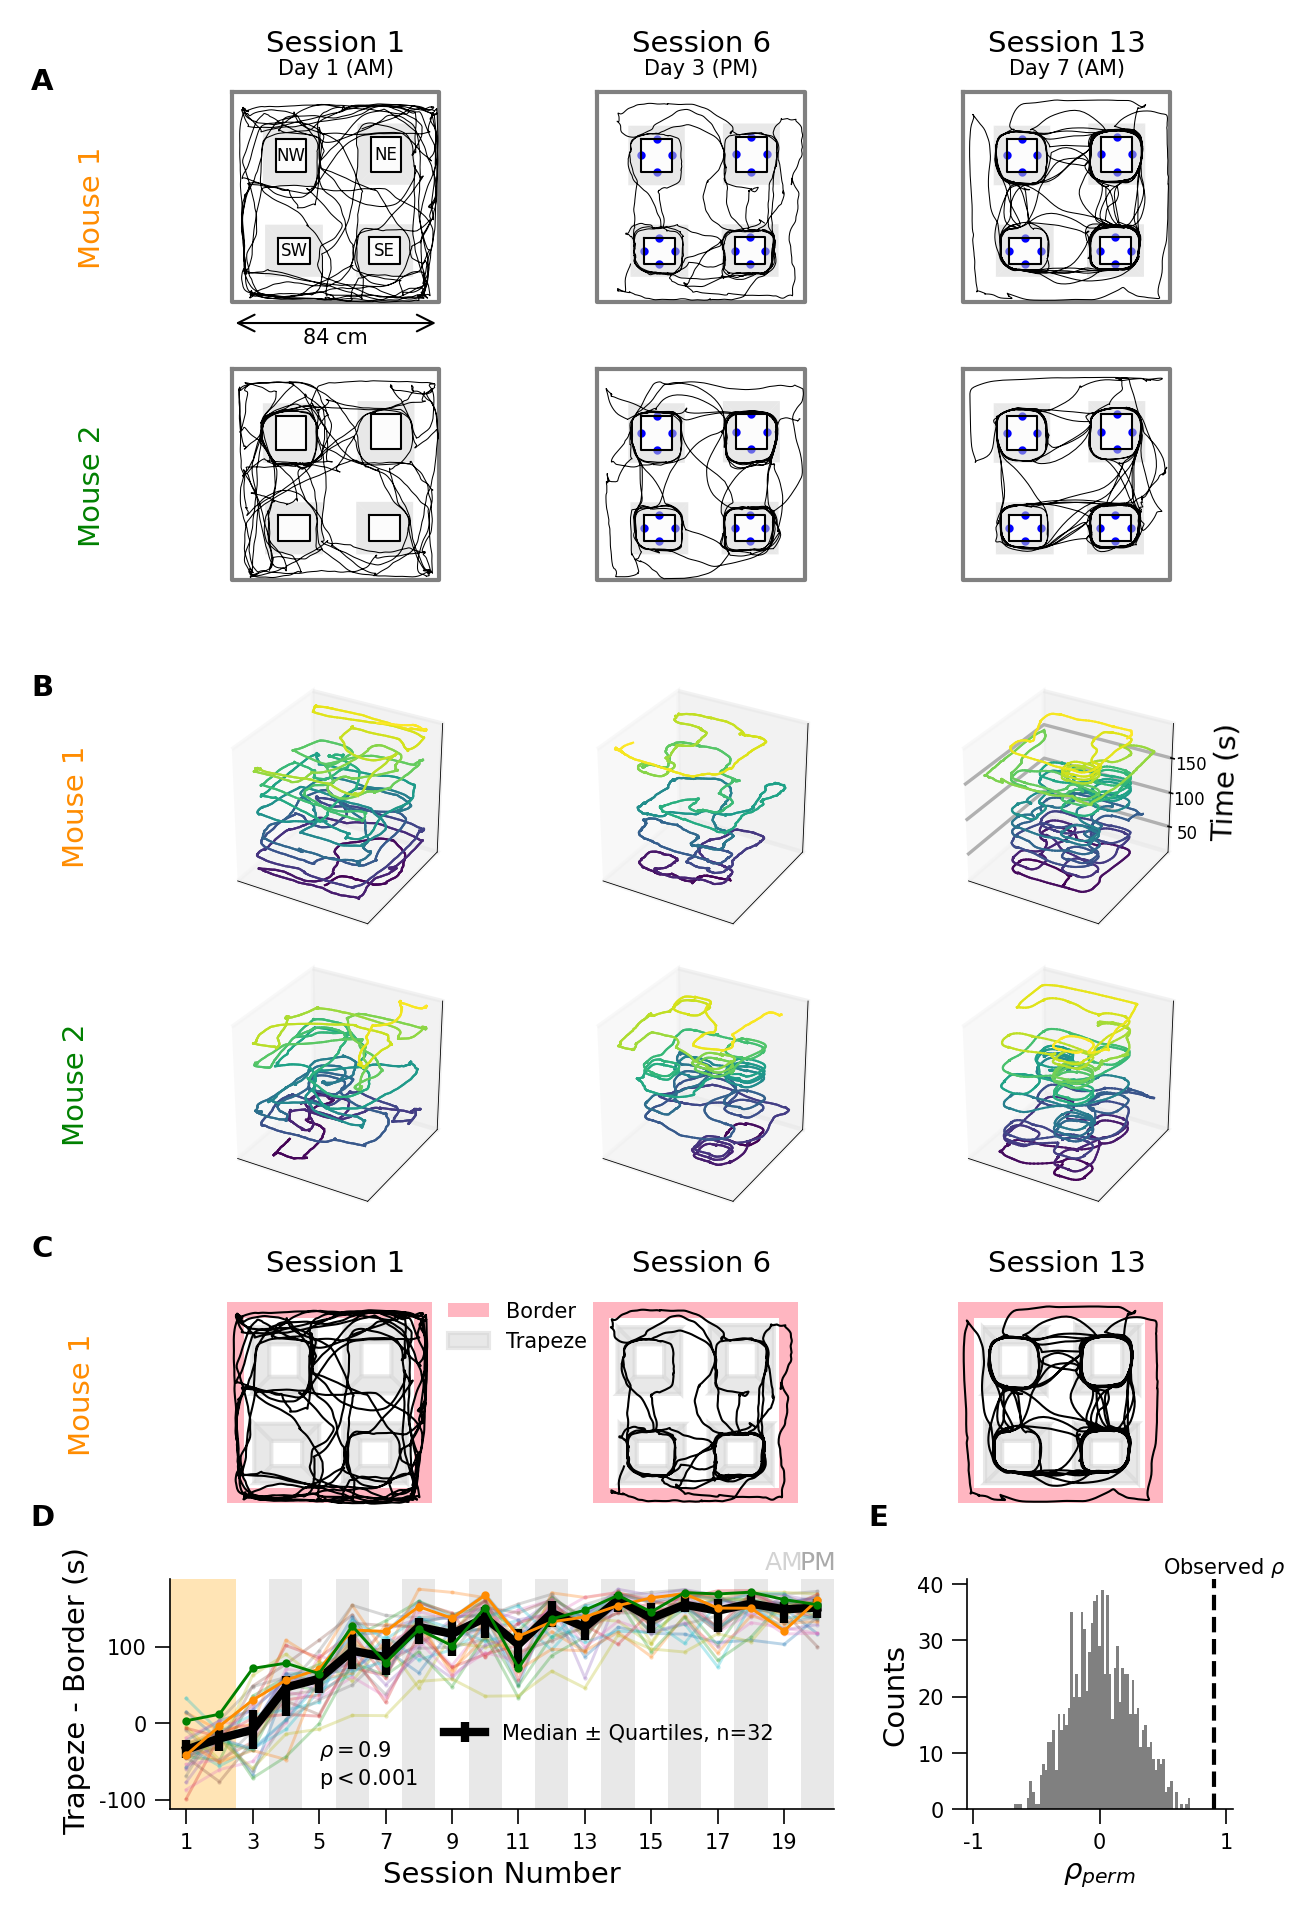

In [19]:
fig = plt.figure(figsize=(cm2inch(12), cm2inch(19)), dpi=300, constrained_layout=False, facecolor='w')

gs = fig.add_gridspec(6, 1 , hspace=0.3)

### Panel A ###

row1 = gs[0:2].subgridspec(2, 3, wspace=.1, hspace=.1, width_ratios=[1, 1, 1])
ax_11 = plt.subplot(row1[0,0], aspect="equal")
ax_12 = plt.subplot(row1[0,1], aspect="equal")
ax_13 = plt.subplot(row1[0,2], aspect="equal")

axs_1top = [ax_11,ax_12,ax_13]
axs_1top = np.array(axs_1top)

plot_mouse_sessions(illustration_mice[0], illustration_sessions_indexes, path_to_data_folder, time_start=time_start, time_end=time_end, axs=axs_1top)

ax_11.text(-0.57, 0.5, 'Mouse 1', color='darkorange',rotation=90, va='center', ha='center', transform=ax_11.transAxes, fontsize=7)

for ax, session_idx in zip([ax_11, ax_12, ax_13], illustration_sessions_indexes):
    day, period = get_day_and_period(session_idx)
    ax.text(0.5, 1.15, f'Session {session_idx + 1}', va='center', ha='center', transform=ax.transAxes, fontsize=7)
    ax.text(0.5, 1.1 - 0.05, f'Day {day} ({period})', va='center', ha='center', transform=ax.transAxes, fontsize=5)

ax_14 = plt.subplot(row1[1,0], aspect="equal")
ax_15 = plt.subplot(row1[1,1], aspect="equal")
ax_16 = plt.subplot(row1[1,2], aspect="equal")

axs_1bot = [ax_14,ax_15,ax_16]
axs_1bot = np.array(axs_1bot)

plot_mouse_sessions(illustration_mice[1], illustration_sessions_indexes, path_to_data_folder, time_start=time_start, time_end=time_end,
                    axs=axs_1bot,showtowerID=False,show_arena_size=False)

ax_14.text(-0.57, 0.5, 'Mouse 2', color='green',rotation=90, va='center', ha='center', transform=ax_14.transAxes, fontsize=7)

fig.text(0.06, 0.88, 'A', weight='bold', va='center', ha='center', fontsize=7)

### Panel B ###

row2 = gs[2:4].subgridspec(2, 3, wspace=.1, hspace=.1, width_ratios=[1, 1, 1])
ax_21 = plt.subplot(row2[0,0], projection="3d", aspect="equal")
ax_22 = plt.subplot(row2[0,1], projection="3d", aspect="equal")
ax_23 = plt.subplot(row2[0,2], projection="3d", aspect="equal")

axs_2top = [ax_21,ax_22,ax_23]
axs_2top = np.array(axs_2top)

plot_3dtrajectory_mice_sessions(illustration_mice[0], illustration_sessions_indexes, path_to_data_folder, time_start=time_start, time_end=time_end,
                                axs=axs_2top, linewidth=0.5,show_last_zticks_info=True)

ax_21.text2D(-0.53, 0.5, 'Mouse 1', color='darkorange',rotation=90, va='center', ha='center', transform=ax_21.transAxes, fontsize=7)

ax_24 = plt.subplot(row2[1,0], projection="3d", aspect="equal")
ax_25 = plt.subplot(row2[1,1], projection="3d", aspect="equal")
ax_26 = plt.subplot(row2[1,2], projection="3d", aspect="equal")

axs_2bot = [ax_24,ax_25,ax_26]
axs_2bot = np.array(axs_2bot)

plot_3dtrajectory_mice_sessions(illustration_mice[1], illustration_sessions_indexes, path_to_data_folder, time_start=time_start, time_end=time_end,
                                axs=axs_2bot, linewidth=0.5,show_last_zticks_info=False)

ax_24.text2D(-0.53, 0.5, 'Mouse 2', color='green',rotation=90, va='center', ha='center', transform=ax_24.transAxes, fontsize=7)

fig.text(0.06, 0.61, 'B', weight='bold', va='center', ha='center', fontsize=7)

### Panel C, D, E ###

row3 = gs[4].subgridspec(1, 3, wspace=.1, hspace=.3, width_ratios=[1, 1, 1])

ax_31 = plt.subplot(row3[0,0], aspect="equal")
ax_32 = plt.subplot(row3[0,1], aspect="equal")
ax_33 = plt.subplot(row3[0,2], aspect="equal")

plot_trajectory_with_trapezes_border(os.path.join(path_to_data_folder, illustration_mice[0]), illustration_sessions_indexes[0], border_zone, trapeze_width,
                                     ax_31, time_start=time_start, time_end=time_end, linewidth=0.5)

plot_trajectory_with_trapezes_border(os.path.join(path_to_data_folder, illustration_mice[0]), illustration_sessions_indexes[1], border_zone, trapeze_width,
                                     ax_32, time_start=time_start, time_end=time_end, linewidth=0.5, show_legend=False)

plot_trajectory_with_trapezes_border(os.path.join(path_to_data_folder, illustration_mice[0]), illustration_sessions_indexes[2], border_zone, trapeze_width,
                                     ax_33, time_start=time_start, time_end=time_end, linewidth=0.5, show_legend=False)

ax_31.set_xlabel(f'Session {illustration_sessions_indexes[0]+1}')
ax_31.xaxis.set_label_position('top') 
ax_31.set_ylabel('Mouse 1', color='darkorange', labelpad=30)
ax_32.set_xlabel(f'Session {illustration_sessions_indexes[1]+1}')
ax_32.xaxis.set_label_position('top') 
ax_33.set_xlabel(f'Session {illustration_sessions_indexes[2]+1}')
ax_33.xaxis.set_label_position('top') 

fig.text(0.06, 0.36, 'C', weight='bold', va='center', ha='center', fontsize=7)

row4 = gs[5].subgridspec(1, 3, wspace=.5, hspace=.3, width_ratios=[1, 1, 1])

ax_41 = plt.subplot(row4[0,:2])
ax_42 = plt.subplot(row4[0,2])

plot_learning_curves_alt_background(mouse_timediff_trapezevsborder_persession, ax_41, mice_to_highlight=illustration_mice,
                     index_offset=first_and_last_session_indexes[0], xlim=xlim_stats, ylabel=' Trapeze - Border (s)', tick_interval=2, legend_loc=(0.4,0.25))

spearman_res = plot_shuffled_spearman_test(mouse_timediff_trapezevsborder_persession, ax_42, shuffle_number=1000, first_and_last_session_indexes=first_and_last_session_indexes_stats)    

# ax_41.text(4,-75, rf'$\rho={np.round(spearman_res.statistic,2)}$', fontsize=5)
pvalue_to_print = rf'p$= {spearman_res.pvalue,3:.3f}$' if spearman_res.pvalue>=0.001 else 'p$<0.001$'
ax_41.text(5,-80, rf'$\rho = {round(spearman_res.statistic,2)}$' + '\n' + pvalue_to_print, fontsize=5, color='k')
ax_42.text(0.5, 42, r'Observed $\rho$', fontsize=5)

ax_41.set_xlim(xlim_stats)

fig.text(0.06, 0.24, 'D', weight='bold', va='center', ha='center', fontsize=7)
fig.text(0.65, 0.24, 'E', weight='bold', va='center', ha='center', fontsize=7)


fig.tight_layout()
plt.subplots_adjust(left=0.15)
plt.savefig("FigureS07.png", facecolor='w', 
                edgecolor='none', bbox_inches='tight', format="png", dpi=300)
    

In [20]:
# Save the figure as a PDF
fig.savefig("FigureS07.pdf", format="pdf", bbox_inches='tight', dpi=300)
